# Proyek Akhir: Menyelesaikan Permasalahan Perusahaan Edutech

- Nama: Herlan Jaelani
- Email: herlanjaelani1507@gmail.com
- Id Dicoding: herlanjae

## Persiapan

### Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import joblib
import os


### Menyiapkan data yang akan diguankan

## Data Understanding

In [2]:
df = pd.read_csv("data/data.csv", encoding="windows-1252", delimiter=";")

if 'ï»¿Marital_status' in df.columns:
    df.rename(columns={'ï»¿Marital_status': 'Marital_status'}, inplace=True)
elif '﻿Marital_status' in df.columns:
    df.rename(columns={'﻿Marital_status': 'Marital_status'}, inplace=True)

print("--- Info Dataset ---")
df.info()

print("\n--- Jumlah Missing Values ---")
print(df.isnull().sum().sum(), "Missing Values")

df_clean = df.copy()
df_clean = df_clean[df_clean['Status'] != 'Enrolled']
df_clean['Status'] = df_clean['Status'].map({'Dropout': 1, 'Graduate': 0})

print("\nDistribusi Status setelah dibersihkan (1=Dropout, 0=Graduate):")
print(df_clean['Status'].value_counts())
print("\nRasio Kelas (%):")
print(df_clean['Status'].value_counts(normalize=True) * 100)

--- Info Dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                     

## Data Preparation / Preprocessing

/tmp/ipykernel_17349/1789884283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_features.values, y=top_features.index, palette='RdBu_r')


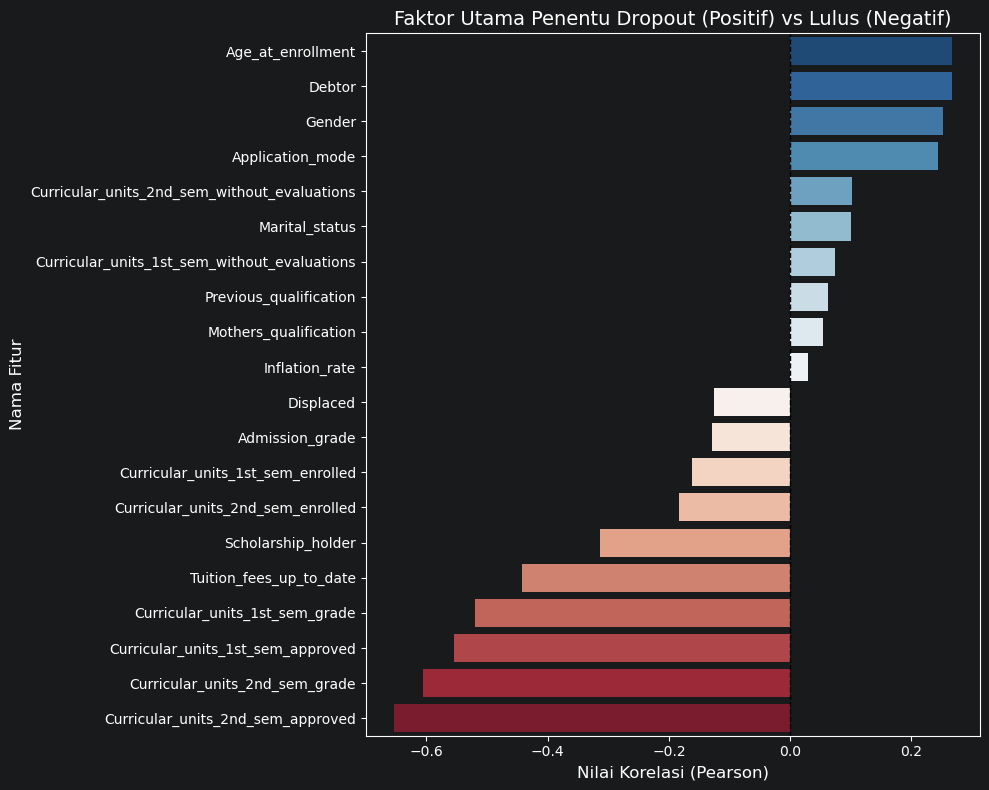

/tmp/ipykernel_17349/1789884283.py:22: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Tidak Punya (0)', 'Punya Hutang (1)'])
/tmp/ipykernel_17349/1789884283.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Menunggak (0)', 'Tepat Waktu (1)'])
/tmp/ipykernel_17349/1789884283.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_clean, x='Status', y='Age_at_enrollment', palette='pastel', ax=axes[2])
/tmp/ipykernel_17349/1789884283.py:32: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Graduate (0)', 'Dropout 

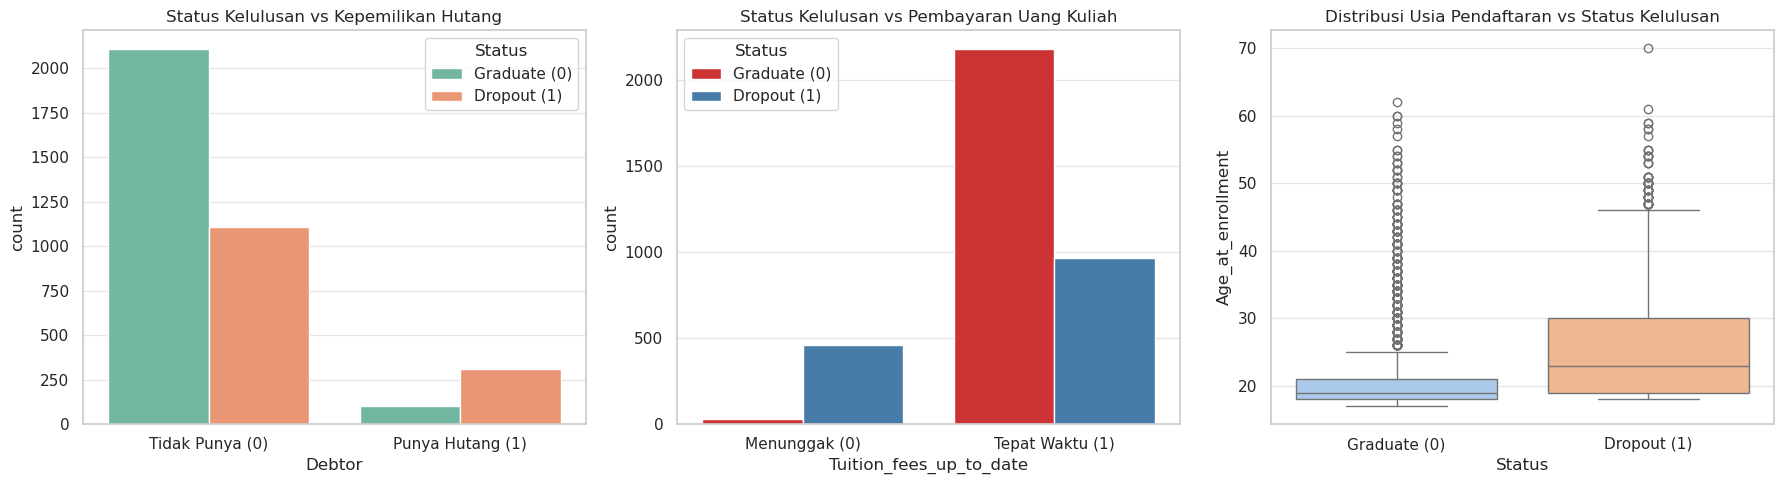

In [3]:
correlation = df_clean.corr()['Status'].sort_values(ascending=False)
correlation = correlation.drop('Status')

top_positive = correlation.head(10)
top_negative = correlation.tail(10)
top_features = pd.concat([top_positive, top_negative])

plt.figure(figsize=(10, 8))
sns.barplot(x=top_features.values, y=top_features.index, palette='RdBu_r')
plt.title('Faktor Utama Penentu Dropout (Positif) vs Lulus (Negatif)', fontsize=14)
plt.xlabel('Nilai Korelasi (Pearson)', fontsize=12)
plt.ylabel('Nama Fitur', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()

sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.countplot(data=df_clean, x='Debtor', hue='Status', palette='Set2', ax=axes[0])
axes[0].set_title('Status Kelulusan vs Kepemilikan Hutang')
axes[0].set_xticklabels(['Tidak Punya (0)', 'Punya Hutang (1)'])
axes[0].legend(title='Status', labels=['Graduate (0)', 'Dropout (1)'])

sns.countplot(data=df_clean, x='Tuition_fees_up_to_date', hue='Status', palette='Set1', ax=axes[1])
axes[1].set_title('Status Kelulusan vs Pembayaran Uang Kuliah')
axes[1].set_xticklabels(['Menunggak (0)', 'Tepat Waktu (1)'])
axes[1].legend(title='Status', labels=['Graduate (0)', 'Dropout (1)'])

sns.boxplot(data=df_clean, x='Status', y='Age_at_enrollment', palette='pastel', ax=axes[2])
axes[2].set_title('Distribusi Usia Pendaftaran vs Status Kelulusan')
axes[2].set_xticklabels(['Graduate (0)', 'Dropout (1)'])

plt.tight_layout()
plt.show()

df_clean.to_csv("data/cleaned_student_data.csv", index=False)


## Modeling

In [4]:
X = df_clean.drop('Status', axis=1)
y = df_clean['Status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Jumlah data training: {X_train.shape[0]}")
print(f"Jumlah data testing: {X_test.shape[0]}")

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)
print("\n✅ Model Random Forest berhasil dilatih!")
os.makedirs('model', exist_ok=True)
joblib.dump(rf_model, 'model/rf_model.joblib')
print("✅ Model berhasil disimpan di direktori 'model/rf_model.joblib'")

Jumlah data training: 2904
Jumlah data testing: 726

✅ Model Random Forest berhasil dilatih!
✅ Model berhasil disimpan di direktori 'model/rf_model.joblib'


## Evaluation

--- Laporan Evaluasi Model ---
Accuracy Score: 92.84%

Classification Report:
              precision    recall  f1-score   support

Graduate (0)       0.92      0.96      0.94       442
 Dropout (1)       0.94      0.88      0.91       284

    accuracy                           0.93       726
   macro avg       0.93      0.92      0.92       726
weighted avg       0.93      0.93      0.93       726



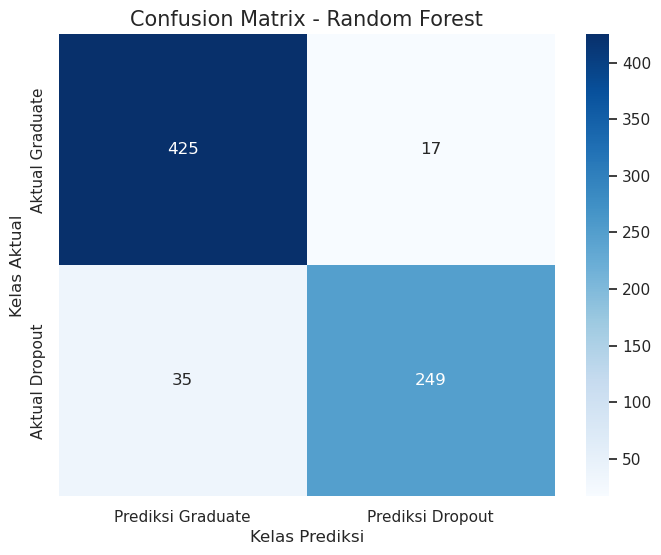

In [5]:
y_pred = rf_model.predict(X_test)
print("--- Laporan Evaluasi Model ---")
print(f"Accuracy Score: {accuracy_score(y_test, y_pred) * 100:.2f}%\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Graduate (0)', 'Dropout (1)']))

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Prediksi Graduate', 'Prediksi Dropout'],
            yticklabels=['Aktual Graduate', 'Aktual Dropout'])
plt.title('Confusion Matrix - Random Forest', fontsize=15)
plt.ylabel('Kelas Aktual', fontsize=12)
plt.xlabel('Kelas Prediksi', fontsize=12)
plt.show()